<a href="https://colab.research.google.com/github/shivanshi-09/Introduction-to-Machine-Learning-/blob/main/A2Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

In [6]:
def kmeans(X, k, max_iter=300, n_init=10, seed=42):
    rng = np.random.default_rng(seed)
    best_labels, best_centers, best_inertia = None, None, np.inf

    for _ in range(n_init):
        idx = rng.choice(len(X), size=k, replace=False)
        centers = X[idx].astype(float)

        for _ in range(max_iter):
            dists = np.linalg.norm(X[:, None] - centers[None], axis=2)
            labels = dists.argmin(axis=1)

            new_centers = np.array([
                X[labels == j].mean(axis=0) if (labels == j).any() else centers[j]
                for j in range(k)
            ])

            if np.allclose(new_centers, centers):
                break
            centers = new_centers
        inertia = sum(np.sum((X[labels == j] - centers[j])**2) for j in range(k))
        if inertia < best_inertia:
            best_labels, best_centers, best_inertia = labels.copy(), centers.copy(), inertia
    return best_labels, best_centers, best_inertia

In [7]:
iris = load_iris()
X = iris.data
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

K_values = [2, 3, 4, 5]
results = {}
for k in K_values:
    labels, centers, inertia = kmeans(X, k)
    results[k] = dict(labels=labels, centers=centers,
                      centers_pca=pca.transform(centers), inertia=inertia)
inertias = [results[k]['inertia'] for k in K_values]


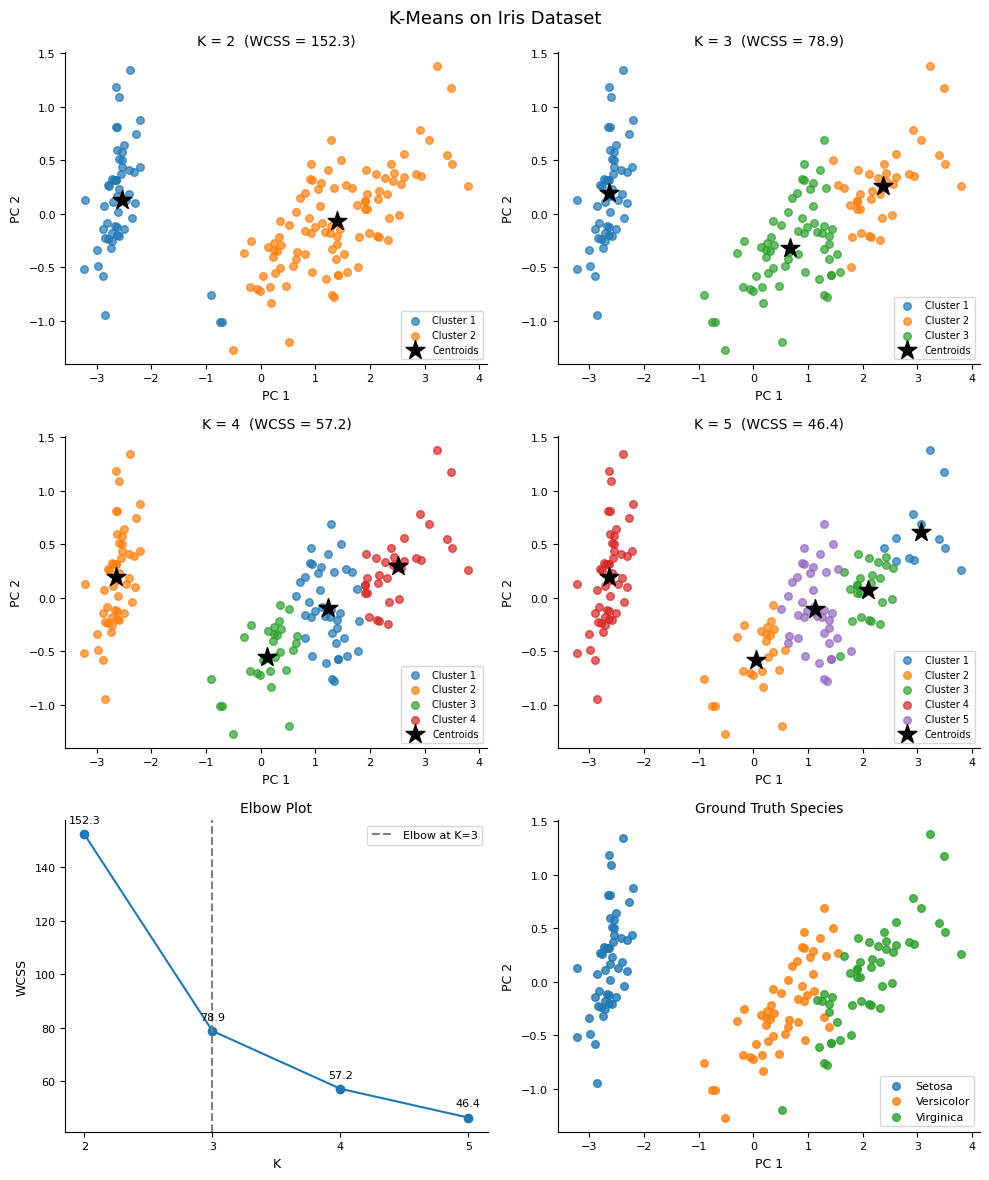

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle('K-Means on Iris Dataset', fontsize=13)

for i, k in enumerate(K_values):
    ax = axes[i // 2][i % 2]
    labels = results[k]['labels']
    centers_pca = results[k]['centers_pca']
    for j in range(k):
        mask = labels == j
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=30, alpha=0.7, label=f'Cluster {j+1}')
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               marker='*', s=200, c='black', zorder=5, label='Centroids')
    ax.set_title(f'K = {k}  (WCSS = {results[k]["inertia"]:.1f})')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.legend(fontsize=7)

ax_elbow = axes[2][0]
ax_elbow.plot(K_values, inertias, 'o-')
for k, inertia in zip(K_values, inertias):
    ax_elbow.annotate(f'{inertia:.1f}', xy=(k, inertia), xytext=(0, 8),
                      textcoords='offset points', ha='center', fontsize=8)
ax_elbow.axvline(3, linestyle='--', color='gray', label='Elbow at K=3')
ax_elbow.set_xlabel('K')
ax_elbow.set_ylabel('WCSS')
ax_elbow.set_title('Elbow Plot')
ax_elbow.set_xticks(K_values)
ax_elbow.legend(fontsize=8)

ax_true = axes[2][1]
for j, name in enumerate(iris.target_names):
    mask = iris.target == j
    ax_true.scatter(X_pca[mask, 0], X_pca[mask, 1], s=30, alpha=0.8, label=name.capitalize())
ax_true.set_title('Ground Truth Species')
ax_true.set_xlabel('PC 1')
ax_true.set_ylabel('PC 2')
ax_true.legend(fontsize=8)

plt.tight_layout()
plt.show()